c:\Users\sa\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\_param_validation.py:11: UserWarning: A NumPy version >=1.23.5 and <2.3.0 is required for this version of SciPy (detected version 2.4.4)
  from scipy.sparse import csr_matrix, issparse


Using device: cuda
base_path = D:\RHJ\DataSet\Raabin WBC
train_path = D:\RHJ\DataSet\Raabin WBC\Train
test_a_path = D:\RHJ\DataSet\Raabin WBC\Test-A
test_b_path = D:\RHJ\DataSet\Raabin WBC\Test-B
Train classes: ['Basophil', 'Eosinophil', 'Lymphocyte', 'Monocyte', 'Neutrophil']
Test-A classes: ['Basophil', 'Eosinophil', 'Lymphocyte', 'Monocyte', 'Neutrophil']
Test-B classes: ['Lymphocyte', 'Neutrophil']
Folders inside dataset:
['Test-A', 'Test-B', 'Train']
Test-A -> ['Basophil', 'Eosinophil', 'Lymphocyte', 'Monocyte', 'Neutrophil']
Test-B -> ['Lymphocyte', 'Neutrophil']
Train -> ['Basophil', 'Eosinophil', 'Lymphocyte', 'Monocyte', 'Neutrophil']
Number of classes: 5

Class names:
Basophil
Eosinophil
Lymphocyte
Monocyte
Neutrophil
Basophil : 212 images
Eosinophil : 744 images
Lymphocyte : 2427 images
Monocyte : 561 images
Neutrophil : 6231 images


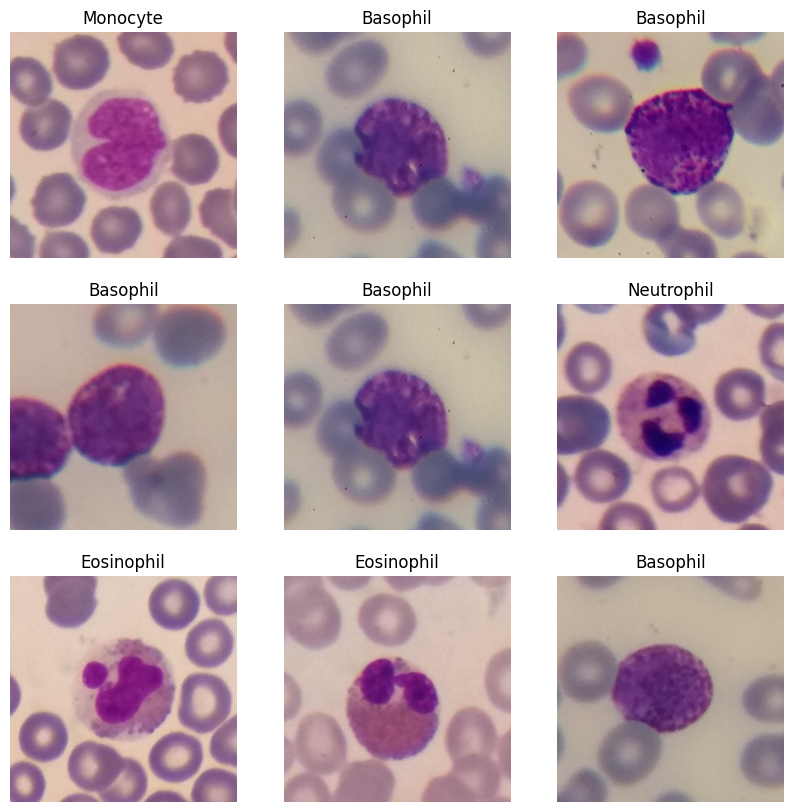

Sample image sizes:
[(575, 575), (575, 575), (575, 575), (575, 575), (575, 575), (575, 575), (575, 575), (575, 575), (575, 575), (575, 575)]


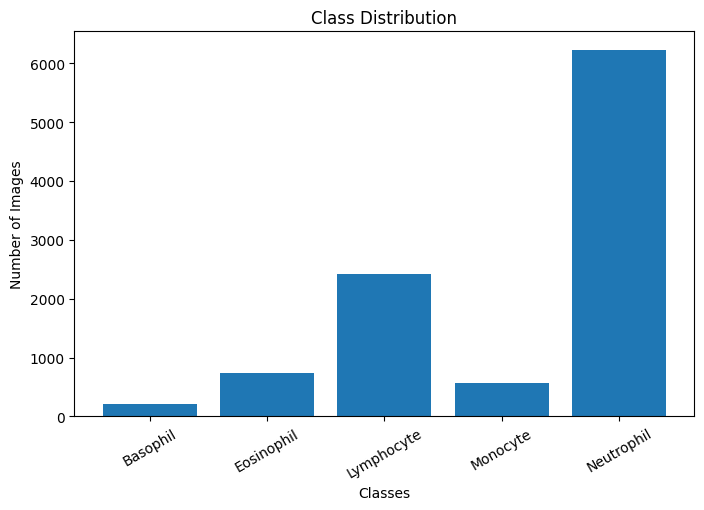

Dataset has class imbalance
Total images: 10175
Training images: 7122
Validation images: 1526
Testing images: 1527
X_train shape: (7122, 224, 224, 3)
X_val shape: (1526, 224, 224, 3)
X_test shape: (1527, 224, 224, 3)


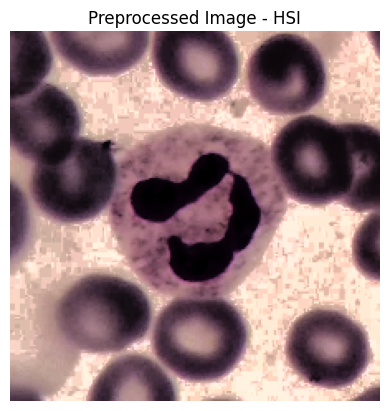

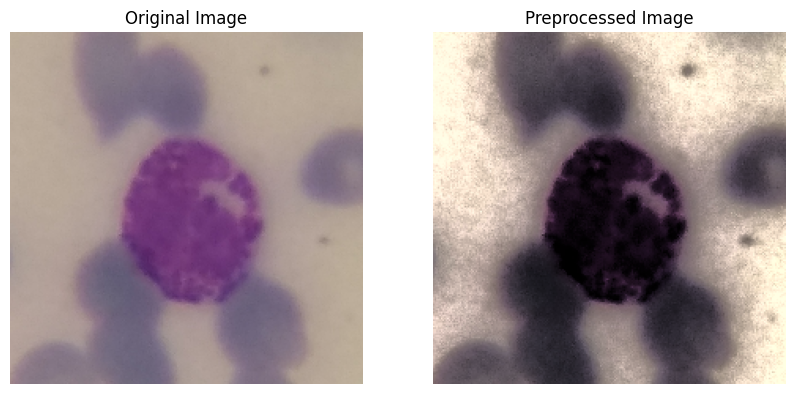

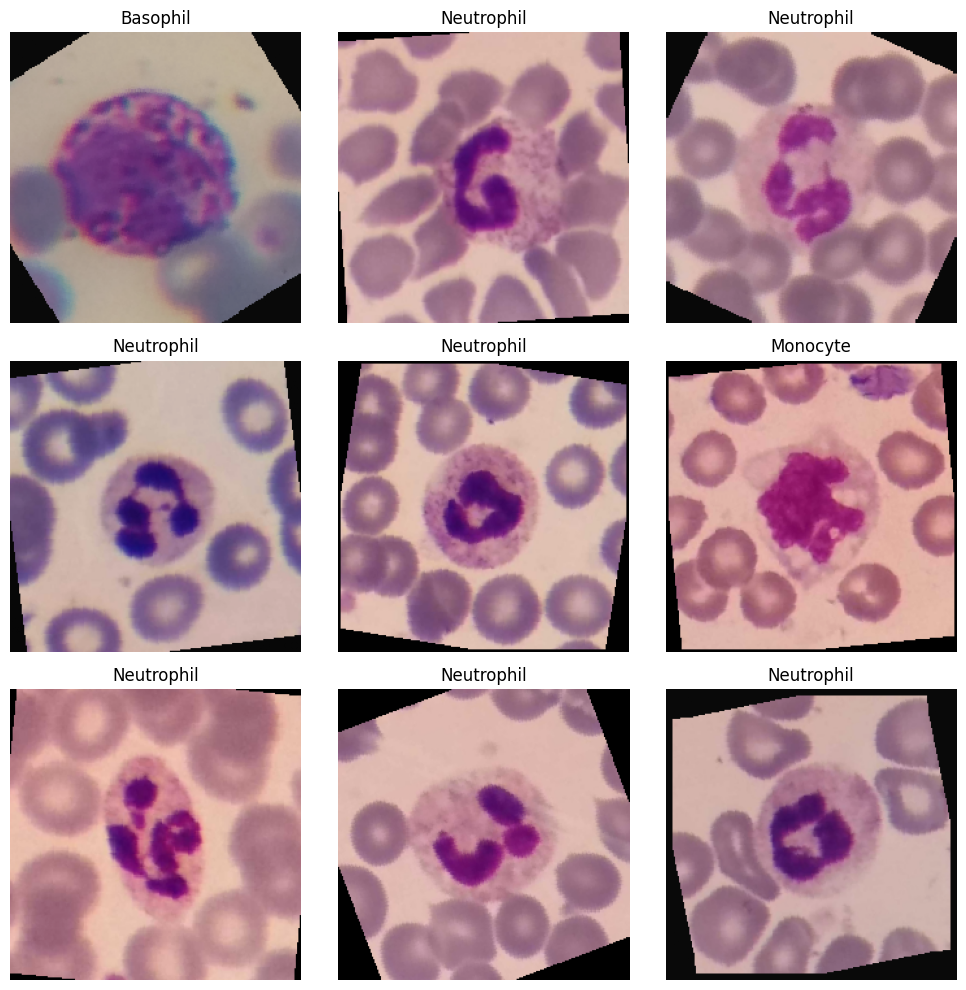

Number of classes: 5
Class names: ['Basophil', 'Eosinophil', 'Lymphocyte', 'Monocyte', 'Neutrophil']
HybridModel(
  (eff): EfficientNet(
    (features): Sequential(
      (0): Conv2dNormActivation(
        (0): Conv2d(3, 24, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (1): BatchNorm2d(24, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
        (2): SiLU(inplace=True)
      )
      (1): Sequential(
        (0): FusedMBConv(
          (block): Sequential(
            (0): Conv2dNormActivation(
              (0): Conv2d(24, 24, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
              (1): BatchNorm2d(24, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
              (2): SiLU(inplace=True)
            )
          )
          (stochastic_depth): StochasticDepth(p=0.0, mode=row)
        )
        (1): FusedMBConv(
          (block): Sequential(
            (0): Conv2dNormActivation(
              (0): Conv2d(24, 2

c:\Users\sa\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


RuntimeError: Tensors must have same number of dimensions: got 2 and 4

In [ ]:
# Import required libraries for file handling and visualization
import os
import matplotlib.pyplot as plt
import numpy as np
import cv2
from sklearn.model_selection import train_test_split
from PIL import Image
import random
import seaborn as sns

# PyTorch Imports
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import datasets, transforms, models

# Setup device for CUDA support
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# ==========================================
# 1. Path Setup & Exploration
# ==========================================
base_path = "D:/RHJ/DataSet/Raabin WBC"
train_path = os.path.join(base_path, 'Train')
test_a_path = os.path.join(base_path, 'Test-A')
test_b_path = os.path.join(base_path, 'Test-B')

print("base_path =", os.path.abspath(base_path))
print("train_path =", os.path.abspath(train_path))
print("test_a_path =", os.path.abspath(test_a_path))
print("test_b_path =", os.path.abspath(test_b_path))

print("Train classes:", os.listdir(train_path))
print("Test-A classes:", os.listdir(test_a_path))
print("Test-B classes:", os.listdir(test_b_path))

# Base transform to mimic Keras image_dataset_from_directory (loads and resizes)
base_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()  # Automatically scales images to [0, 1]
])

# PyTorch Datasets for initial inspection
train_dataset = datasets.ImageFolder(train_path, transform=base_transform)
val_dataset = datasets.ImageFolder(test_a_path, transform=base_transform)

train_loader_initial = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader_initial = DataLoader(val_dataset, batch_size=32, shuffle=False)

print("Folders inside dataset:")
print(os.listdir(base_path))

for folder in os.listdir(base_path):
    folder_path = os.path.join(base_path, folder)
    if os.path.isdir(folder_path):
        print(folder, "->", os.listdir(folder_path))

classes = train_dataset.classes
print("Number of classes:", len(classes))

print("\nClass names:")
for c in classes:
    print(c)

# Count number of images in each class
class_counts = {}
for class_name in classes:
    class_path = os.path.join(train_path, class_name)
    if os.path.isdir(class_path):
        images = os.listdir(class_path)
        class_counts[class_name] = len(images)
        print(class_name, ":", len(images), "images")

# ==========================================
# 2. Visualizations & HSI Preprocessing 
# ==========================================
# Display sample images from the dataset
plt.figure(figsize=(10, 10))
for i in range(9):
    class_name = random.choice(classes)
    class_path = os.path.join(train_path, class_name)
    img_name = random.choice(os.listdir(class_path))
    img_path = os.path.join(class_path, img_name)
    img = Image.open(img_path)
    
    plt.subplot(3, 3, i + 1)
    plt.imshow(img)
    plt.title(class_name)
    plt.axis("off")
plt.show()

# Check sample image sizes
image_sizes = []
for class_name in classes:
    class_path = os.path.join(train_path, class_name)
    images = os.listdir(class_path)[:5]
    for img_name in images:
        img_path = os.path.join(class_path, img_name)
        try:
            img = Image.open(img_path)
            image_sizes.append(img.size)
        except:
            pass

print("Sample image sizes:")
print(image_sizes[:10])

# Plot dataset class distribution
plt.figure(figsize=(8, 5))
plt.bar(class_counts.keys(), class_counts.values())
plt.title("Class Distribution")
plt.xlabel("Classes")
plt.ylabel("Number of Images")
plt.xticks(rotation=30)
plt.show()

# Check for imbalance
max_count = max(class_counts.values())
min_count = min(class_counts.values())
if max_count - min_count > 0:
    print("Dataset has class imbalance")
else:
    print("Dataset is balanced")

# Collect image paths and labels manually for splitting
image_paths = []
labels = []

for class_name in os.listdir(train_path):
    class_path = os.path.join(train_path, class_name)
    if os.path.isdir(class_path):
        for img in os.listdir(class_path):
            image_paths.append(os.path.join(class_path, img))
            labels.append(class_name)

print("Total images:", len(image_paths))

# Manual splitting matching your exact flow
train_imgs, temp_imgs, train_labels, temp_labels = train_test_split(
    image_paths, labels, test_size=0.30, stratify=labels, random_state=42
)
val_imgs, test_imgs, val_labels, test_labels = train_test_split(
    temp_imgs, temp_labels, test_size=0.50, stratify=temp_labels, random_state=42
)

print("Training images:", len(train_imgs))
print("Validation images:", len(val_imgs))
print("Testing images:", len(test_imgs))

# HSI Logic (Kept exactly identical as it relies purely on numpy/cv2)
def rgb_to_hsi(img):
    img = img.astype(np.float32) / 255.0
    R, G, B = img[:, :, 0], img[:, :, 1], img[:, :, 2]
    I = (R + G + B) / 3.0
    min_rgb = np.minimum(np.minimum(R, G), B)
    S = np.zeros_like(I)
    denom = R + G + B
    mask = denom > 1e-8
    S[mask] = 1 - (3 * min_rgb[mask] / denom[mask])
    num = 0.5 * ((R - G) + (R - B))
    den = np.sqrt((R - G)**2 + (R - B) * (G - B)) + 1e-8
    theta = np.arccos(np.clip(num / den, -1, 1))
    H = np.zeros_like(I)
    H[B <= G] = theta[B <= G]
    H[B > G] = 2 * np.pi - theta[B > G]
    H = H / (2 * np.pi) 
    return np.stack([H, S, I], axis=-1)

def hsi_to_rgb(hsi):
    H = hsi[:, :, 0] * 2 * np.pi
    S = hsi[:, :, 1]
    I = hsi[:, :, 2]
    R, G, B = np.zeros_like(I), np.zeros_like(I), np.zeros_like(I)
    
    mask1 = (H >= 0) & (H < 2 * np.pi / 3)
    B[mask1] = I[mask1] * (1 - S[mask1])
    R[mask1] = I[mask1] * (1 + (S[mask1] * np.cos(H[mask1])) / (np.cos(np.pi / 3 - H[mask1]) + 1e-8))
    G[mask1] = 3 * I[mask1] - (R[mask1] + B[mask1])

    mask2 = (H >= 2 * np.pi / 3) & (H < 4 * np.pi / 3)
    H2 = H[mask2] - 2 * np.pi / 3
    R[mask2] = I[mask2] * (1 - S[mask2])
    G[mask2] = I[mask2] * (1 + (S[mask2] * np.cos(H2)) / (np.cos(np.pi / 3 - H2) + 1e-8))
    B[mask2] = 3 * I[mask2] - (R[mask2] + G[mask2])

    mask3 = (H >= 4 * np.pi / 3) & (H < 2 * np.pi)
    H3 = H[mask3] - 4 * np.pi / 3
    G[mask3] = I[mask3] * (1 - S[mask3])
    B[mask3] = I[mask3] * (1 + (S[mask3] * np.cos(H3)) / (np.cos(np.pi / 3 - H3) + 1e-8))
    R[mask3] = 3 * I[mask3] - (G[mask3] + B[mask3])

    rgb = np.stack([R, G, B], axis=-1)
    rgb = np.clip(rgb, 0, 1)
    return (rgb * 255).astype(np.uint8)

def preprocess_image_hsi(img_path, size=(224, 224)):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, size)
    hsi = rgb_to_hsi(img)
    H, S, I = hsi[:, :, 0], hsi[:, :, 1], hsi[:, :, 2]
    I_uint8 = np.clip(I * 255, 0, 255).astype(np.uint8)
    I_eq = cv2.equalizeHist(I_uint8).astype(np.float32) / 255.0
    hsi_eq = np.stack([H, S, I_eq], axis=-1)
    img_eq = hsi_to_rgb(hsi_eq)
    return img_eq.astype("float32") / 255.0

X_train = np.array([preprocess_image_hsi(p) for p in train_imgs])
X_val   = np.array([preprocess_image_hsi(p) for p in val_imgs])
X_test  = np.array([preprocess_image_hsi(p) for p in test_imgs])

print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)
print("X_test shape:", X_test.shape)

sample = preprocess_image_hsi(train_imgs[0])
plt.imshow(sample)
plt.title("Preprocessed Image - HSI")
plt.axis("off")
plt.show()

sample_class = classes[0]
sample_image_name = os.listdir(os.path.join(train_path, sample_class))[0]
sample_image_path = os.path.join(train_path, sample_class, sample_image_name)

original = cv2.imread(sample_image_path)
original = cv2.cvtColor(original, cv2.COLOR_BGR2RGB)
original = cv2.resize(original, (224, 224))
processed = preprocess_image_hsi(sample_image_path)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(original)
plt.title("Original Image")
plt.axis("off")
plt.subplot(1, 2, 2)
plt.imshow(processed)
plt.title("Preprocessed Image")
plt.axis("off")
plt.show()

# ==========================================
# 3. Data Augmentation & Loaders
# ==========================================
# PyTorch equivalent of your TF Data Augmentation sequence
data_augmentation = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(36),          # 0.1 of 360 degrees
    transforms.RandomAffine(0, scale=(0.9, 1.1)), # Zoom
    transforms.ColorJitter(contrast=0.1),
    transforms.ToTensor()
])

augmented_train_dataset = datasets.ImageFolder(train_path, transform=data_augmentation)
val_dataset = datasets.ImageFolder(test_a_path, transform=base_transform)
test_dataset = datasets.ImageFolder(test_b_path, transform=base_transform)

train_loader = DataLoader(augmented_train_dataset, batch_size=32, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

class_names = augmented_train_dataset.classes

# Plot augmented samples
plt.figure(figsize=(10, 10))
data_iter = iter(train_loader)
images, labels = next(data_iter)

for i in range(min(9, len(images))):
    ax = plt.subplot(3, 3, i + 1)
    img = images[i].permute(1, 2, 0).numpy() # Convert from C,H,W to H,W,C
    plt.imshow(img)
    plt.title(class_names[labels[i]])
    plt.axis("off")
plt.tight_layout()
plt.show()

# ==========================================
# 4. Model Definition (Hybrid)
# ==========================================
num_classes = len(class_names)
print("Number of classes:", num_classes)
print("Class names:", class_names)

class HybridModel(nn.Module):
    def __init__(self, num_classes):
        super(HybridModel, self).__init__()
        
        # Base 1: EfficientNetV2_S
        self.eff = models.efficientnet_v2_s(weights=models.EfficientNet_V2_S_Weights.IMAGENET1K_V1)
        eff_out_features = self.eff.classifier[1].in_features
        # EfficientNet flattens BEFORE the classifier, so replacing the whole block is fine
        self.eff.classifier = nn.Identity() 
        
        # Base 2: ConvNeXt_Tiny
        self.conv = models.convnext_tiny(weights=models.ConvNeXt_Tiny_Weights.IMAGENET1K_V1)
        conv_out_features = self.conv.classifier[2].in_features
        # FIX: Only replace the final Linear layer (index 2). 
        # This safely preserves LayerNorm2d (index 0) and Flatten (index 1)
        self.conv.classifier[2] = nn.Identity() 
        
        # Freeze both bases initially
        for param in self.eff.parameters():
            param.requires_grad = False
        for param in self.conv.parameters():
            param.requires_grad = False
            
        # Fusion head matching TF dense layers
        self.fc1 = nn.Linear(eff_out_features + conv_out_features, 256)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.3)
        self.fc2 = nn.Linear(256, num_classes)
        
    def forward(self, x):
        # Extract features
        eff_features = self.eff(x)
        conv_features = self.conv(x)
        
        # Concatenate features (Now both are strictly 2D [batch_size, features])
        fused_features = torch.cat((eff_features, conv_features), dim=1)
        
        # Dense layers
        x = self.fc1(fused_features)
        x = self.relu(x)
        x = self.dropout(x)
        outputs = self.fc2(x)
        return outputs

# Re-initialize the model to apply the fix
hybrid_model = HybridModel(num_classes).to(device)

# (Make sure to re-initialize the optimizer here too so it registers the new model parameters)
optimizer = optim.Adam(hybrid_model.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2, verbose=True)

# Emulating ReduceLROnPlateau
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2, verbose=True)

# Training loop abstraction to handle Keras-like epochs and history tracking
def train_eval_loop(model, train_loader, val_loader, optimizer, criterion, scheduler, epochs, save_name="best_hybrid_model.pth"):
    history = {'accuracy': [], 'loss': [], 'val_accuracy': [], 'val_loss': []}
    best_val_acc = 0.0
    patience = 3 # For EarlyStopping
    trigger_times = 0

    for epoch in range(epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
        train_loss = running_loss / total
        train_acc = correct / total
        
        model.eval()
        val_loss, v_correct, v_total = 0.0, 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * images.size(0)
                _, predicted = torch.max(outputs.data, 1)
                v_total += labels.size(0)
                v_correct += (predicted == labels).sum().item()
                
        val_loss = val_loss / v_total
        val_acc = v_correct / v_total
        
        history['loss'].append(train_loss)
        history['accuracy'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_accuracy'].append(val_acc)
        
        print(f"Epoch {epoch+1}/{epochs} - loss: {train_loss:.4f} - accuracy: {train_acc:.4f} - val_loss: {val_loss:.4f} - val_accuracy: {val_acc:.4f}")
        
        scheduler.step(val_loss)
        
        # Model Checkpoint
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), save_name)
            trigger_times = 0
            print(f"--> Saved best model to {save_name}")
        else:
            trigger_times += 1
            if trigger_times >= patience:
                print("Early stopping triggered!")
                break
                
    # Restore best weights
    model.load_state_dict(torch.load(save_name))
    return history

print("--- Starting Initial Training ---")
history_hybrid = train_eval_loop(hybrid_model, train_loader, val_loader, optimizer, criterion, scheduler, epochs=8)

# ==========================================
# 6. Fine Tuning Phase
# ==========================================
print("--- Starting Fine-Tuning Phase ---")
# Unfreeze top layers. TF was `eff_base.layers[:-30]`. 
# We replicate this by unfreezing the last ~30 parameters inside the feature extractors.
def unfreeze_last_n_params(module, n=30):
    params = list(module.parameters())
    for p in params[:-n]:
        p.requires_grad = False
    for p in params[-n:]:
        p.requires_grad = True

unfreeze_last_n_params(hybrid_model.eff, n=30)
unfreeze_last_n_params(hybrid_model.conv, n=30)

# Recompile equivalent (Adam lr=1e-5)
optimizer_ft = optim.Adam(filter(lambda p: p.requires_grad, hybrid_model.parameters()), lr=1e-5)
scheduler_ft = optim.lr_scheduler.ReduceLROnPlateau(optimizer_ft, mode='min', factor=0.5, patience=2, verbose=True)

history_hybrid_ft = train_eval_loop(hybrid_model, train_loader, val_loader, optimizer_ft, criterion, scheduler_ft, epochs=5, save_name="best_hybrid_model_ft.pth")

# ==========================================
# 7. Evaluation & Metrics
# ==========================================
def evaluate_model(model, loader):
    model.eval()
    test_loss, correct, total = 0.0, 0, 0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            test_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            
    return test_loss / total, correct / total, np.array(all_preds), np.array(all_labels)

test_loss, test_acc, _, _ = evaluate_model(hybrid_model, test_loader)
print("Hybrid Test Loss:", test_loss)
print("Hybrid Test Accuracy:", test_acc)

# Load best saved fine-tuned model (Optional, we already loaded it in the training loop abstraction)
best_hybrid_model = hybrid_model
best_hybrid_model.load_state_dict(torch.load("best_hybrid_model_ft.pth"))

best_test_loss, best_test_acc, y_pred, y_true = evaluate_model(best_hybrid_model, test_loader)
print("Best Hybrid Test Loss:", best_test_loss)
print("Best Hybrid Test Accuracy:", best_test_acc)

from sklearn.metrics import classification_report, confusion_matrix
print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Hybrid Model Confusion Matrix")
plt.show()

# ==========================================
# 8. Plotting Training History
# ==========================================
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history_hybrid['accuracy'], label='Train Accuracy')
plt.plot(history_hybrid['val_accuracy'], label='Validation Accuracy')
plt.title('Hybrid Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_hybrid['loss'], label='Train Loss')
plt.plot(history_hybrid['val_loss'], label='Validation Loss')
plt.title('Hybrid Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.show()

# Fine-tuning plot
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history_hybrid_ft['accuracy'], label='Fine-tune Train Accuracy')
plt.plot(history_hybrid_ft['val_accuracy'], label='Fine-tune Validation Accuracy')
plt.title('Hybrid Fine-Tuning Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_hybrid_ft['loss'], label='Fine-tune Train Loss')
plt.plot(history_hybrid_ft['val_loss'], label='Fine-tune Validation Loss')
plt.title('Hybrid Fine-Tuning Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.show()

# Sample predictions visualization
plt.figure(figsize=(12, 12))
data_iter = iter(test_loader)
images, labels = next(data_iter)
best_hybrid_model.eval()

with torch.no_grad():
    outputs = best_hybrid_model(images.to(device))
    _, preds = torch.max(outputs, 1)

for i in range(min(9, len(images))):
    ax = plt.subplot(3, 3, i + 1)
    img = images[i].permute(1, 2, 0).numpy()
    plt.imshow(img)
    plt.title(f"True: {class_names[labels[i]]}\nPred: {class_names[preds[i]]}")
    plt.axis("off")
plt.tight_layout()
plt.show()

# ==========================================
# 9. Feature Extraction Logic 
# (Matching the dangling pytorch block at your file end)
# ==========================================
# To extract purely the features, we bypass our fusion head.
# The user snippet asked to remove classifier. In our HybridModel, it's `fc2` and before.
class FeatureExtractor(nn.Module):
    def __init__(self, trained_hybrid_model):
        super(FeatureExtractor, self).__init__()
        # Take the feature streams + fusion layer, but stop before final classification
        self.eff = trained_hybrid_model.eff
        self.conv = trained_hybrid_model.conv
        self.fc1 = trained_hybrid_model.fc1
        
    def forward(self, x):
        eff_features = self.eff(x)
        conv_features = self.conv(x)
        fused = torch.cat((eff_features, conv_features), dim=1)
        features = self.fc1(fused)
        return features

extractor = FeatureExtractor(best_hybrid_model).to(device)
extractor.eval()

def extract_features(model, loader, device):
    all_features = []
    all_labels = []
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            features = model(images)
            all_features.append(features.cpu().numpy())
            all_labels.append(labels.numpy())

    return np.concatenate(all_features, axis=0), np.concatenate(all_labels, axis=0)

# (Reusing the dataloaders we initialized at the start without augmentation for raw feature extraction)
raw_train_loader = DataLoader(datasets.ImageFolder(train_path, transform=base_transform), batch_size=32, shuffle=False)

X_train_feat, y_train_feat = extract_features(extractor, raw_train_loader, device)
X_val_feat, y_val_feat = extract_features(extractor, val_loader, device)
X_test_feat, y_test_feat = extract_features(extractor, test_loader, device)

print("Train Features:", X_train_feat.shape)
print("Val Features:", X_val_feat.shape)
print("Test Features:", X_test_feat.shape)